# Phase 2: Exploratory Data Analysis (EDA)
## Credit Card Fraud Detection System (Deep Learning Portfolio)

### Objectives:
1. **Understand Feature Distributions**: Inspect continuous and categorical variables.
2. **Quantify Class Imbalance**: Highlight the 1.5% fraud rate and explain the business implications.
3. **Identify Fraud Signals**: Analyze how distributions shift between legitimate and fraudulent transactions.
4. **Temporal Patterns**: Explore transaction-hour behaviors and establish the need for cyclical time encoding.
5. **Correlation Heatmap**: Inspect relationships and rule out multicollinearity.
6. **Formulate Preprocessing Strategy**: Plan feature scaling, dropping irrelevant features, and encoding categories for Phase 3.

---

## 1. Setup & Configuration

We load the required Python libraries, configure our plotting theme for visual excellence, and import our custom utilities for seed setting and figure saving.

We'll use a curated color palette: **Blue (#2b5c8f)** for legitimate transactions and **Red-Orange (#d95f02)** for fraudulent transactions.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

# Add project root to sys.path to enable src.* imports
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import load_data
from src.utils import set_seed, save_figure

# Set random seed for reproducibility
set_seed(42)

# Set custom plotting styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["figure.dpi"] = 100

# Custom class palette (supporting both int and str keys for seaborn)
PALETTE = {0: "#2b5c8f", 1: "#d95f02", "0": "#2b5c8f", "1": "#d95f02"}



Random seed set to 42


## 2. Data Loading & Basic Inspection

We load the dataset using `load_data()` from `src/preprocessing.py`. This reads `data/credit_card_fraud_10k.csv` into a Pandas DataFrame.

In [7]:
# Load the data
df = load_data("data/credit_card_fraud_10k.csv")

# Print dataset dimensions
print(f"Dataset shape: {df.shape}")
print("-" * 50)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 781.4 KB
Dataset loaded successfully. Shape: (10000, 10)
 head: 
   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Tr

In [8]:
# Preview first few rows
df.head()


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


We check for any missing values across columns.

In [9]:
# Missing value count
df.isnull().sum()


transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

We compute summary statistics for all numerical features to examine ranges, means, and standard deviations.

In [10]:
# Statistical summary
df.describe()


,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


### Initial Observations:
1. **Zero Missing Values**: The dataset is fully populated, so imputation is not required.
2. **Column Scale Disparity**: Features like `amount` range from \$0 to \$1,471 with a mean of \$175, while `velocity_last_24h` is a count feature from 0 to 9. We will need scaling to ensure stable gradient flow.
3. **`transaction_id`**: This column is a unique record index. It contains no predictive power and will be dropped to prevent data leakage.


## 3. Class Imbalance Analysis

In fraud detection, the target class (`is_fraud`) is typically very rare. We compute the exact distribution and visualize it.

Legitimate (0): 9849 (98.49%)
Fraudulent (1): 151 (1.51%)
Imbalance Ratio: 65.2 : 1


/tmp/ipykernel_24380/2813970245.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='is_fraud', palette=PALETTE, ax=ax)
/tmp/ipykernel_24380/2813970245.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Legitimate", "Fraud"])


Figure saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/class_distribution.png


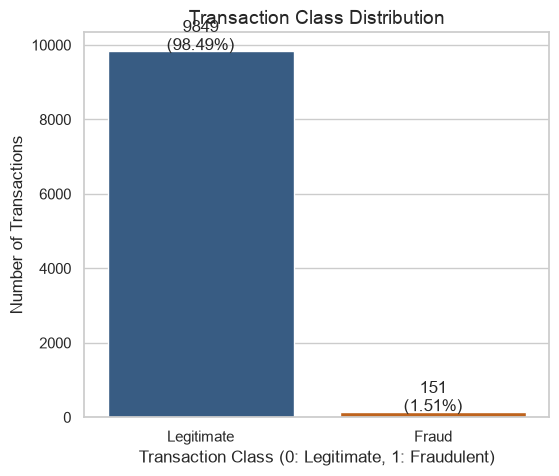

In [6]:
# Calculate class distributions
counts = df['is_fraud'].value_counts()
pcts = df['is_fraud'].value_counts(normalize=True) * 100

print(f"Legitimate (0): {counts[0]} ({pcts[0]:.2f}%)")
print(f"Fraudulent (1): {counts[1]} ({pcts[1]:.2f}%)")
print(f"Imbalance Ratio: {counts[0]/counts[1]:.1f} : 1")

# Plot the distribution
fig, ax = plt.subplots(figsize=(6, 5))
sns.countplot(data=df, x='is_fraud', palette=PALETTE, ax=ax)
ax.set_title("Transaction Class Distribution")
ax.set_xlabel("Transaction Class (0: Legitimate, 1: Fraudulent)")
ax.set_ylabel("Number of Transactions")
ax.set_xticklabels(["Legitimate", "Fraud"])

# Annotate bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{int(height)}\n({height/len(df)*100:.2f}%)", 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

save_figure(fig, "class_distribution.png")
plt.show()


> [!IMPORTANT]
> **Business Perspective**: With a fraud rate of **1.51%**, a naive, zero-skill classifier that predicts "always legitimate" gets **98.49% accuracy** but **0% recall**. 
>
> In the financial domain, a false negative (missing a fraudster) is roughly **20x more costly** than a false positive (a false alert). We must optimize for **PR-AUC** and **Recall** rather than accuracy.


## 4. Univariate Numeric Feature Analysis (Split by Class)

We examine the distributions of continuous features (`amount`, `device_trust_score`, `cardholder_age`, `velocity_last_24h`, and `transaction_hour`) by class to identify features with high discriminative power.

/tmp/ipykernel_24380/2293891917.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_fraud', y=col, palette=PALETTE, ax=axes[1])
/tmp/ipykernel_24380/2293891917.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["Legitimate", "Fraud"])


Figure saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/distribution_amount.png


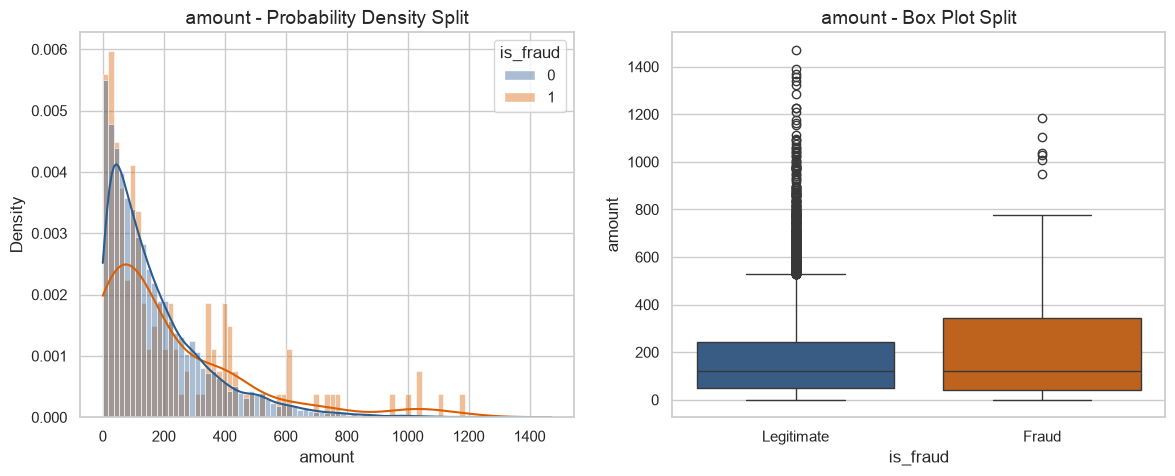

/tmp/ipykernel_24380/2293891917.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_fraud', y=col, palette=PALETTE, ax=axes[1])
/tmp/ipykernel_24380/2293891917.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["Legitimate", "Fraud"])


Figure saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/distribution_device_trust_score.png


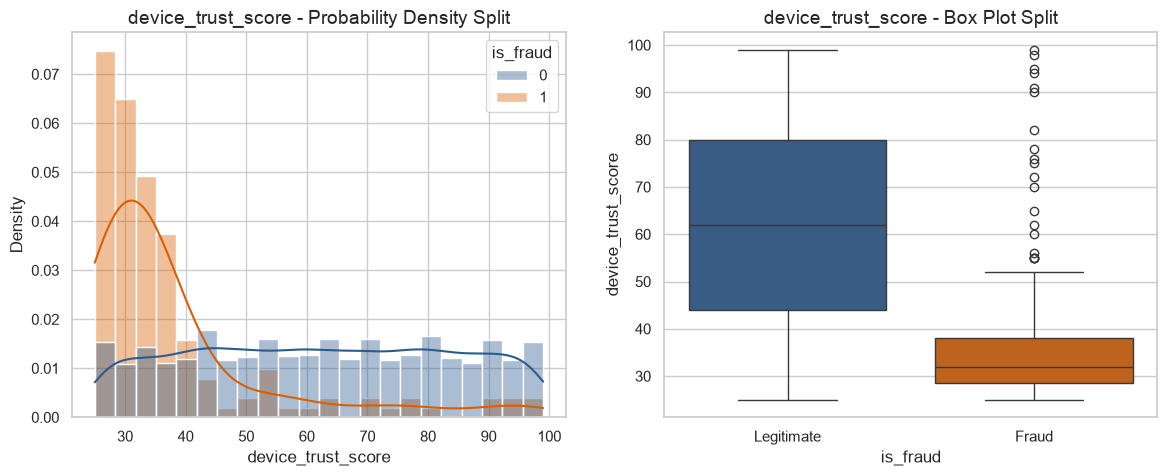

/tmp/ipykernel_24380/2293891917.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_fraud', y=col, palette=PALETTE, ax=axes[1])
/tmp/ipykernel_24380/2293891917.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["Legitimate", "Fraud"])


Figure saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/distribution_cardholder_age.png


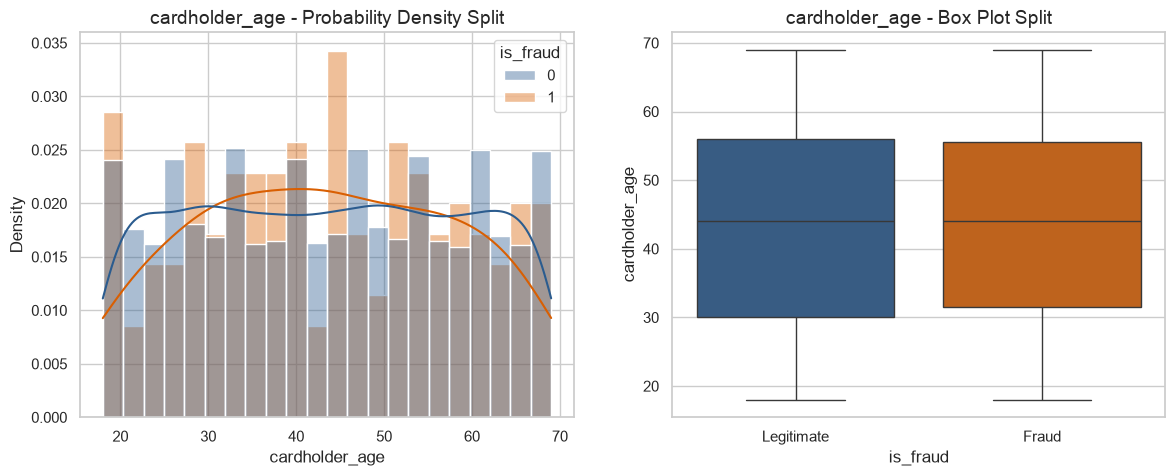

/tmp/ipykernel_24380/2293891917.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_fraud', y=col, palette=PALETTE, ax=axes[1])
/tmp/ipykernel_24380/2293891917.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["Legitimate", "Fraud"])


Figure saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/distribution_velocity_last_24h.png


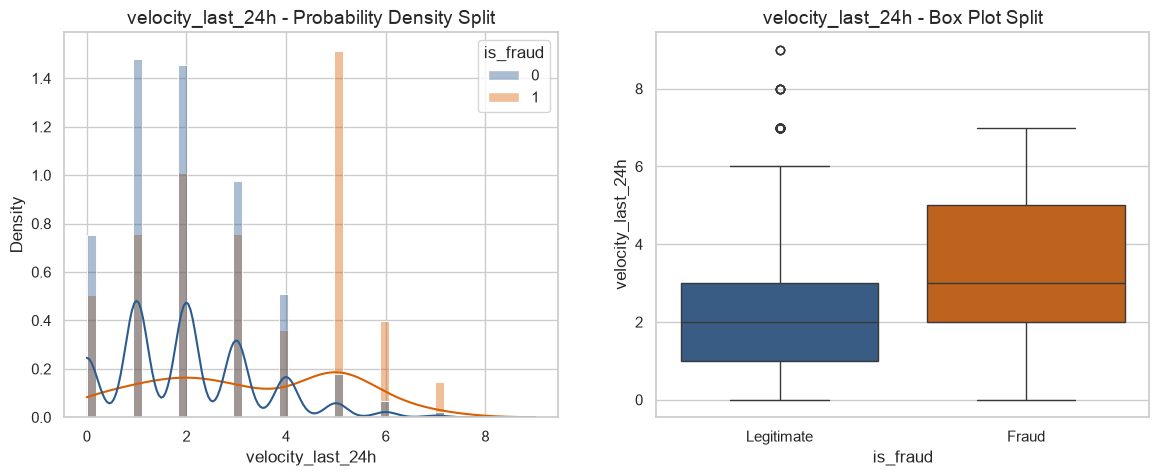

/tmp/ipykernel_24380/2293891917.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_fraud', y=col, palette=PALETTE, ax=axes[1])
/tmp/ipykernel_24380/2293891917.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(["Legitimate", "Fraud"])


Figure saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/distribution_transaction_hour.png


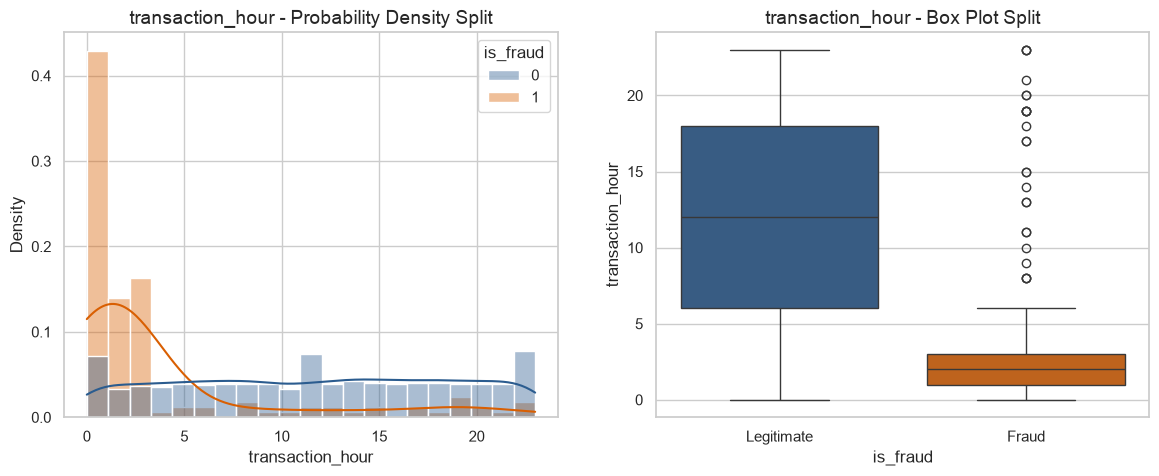

In [7]:
numeric_cols = ['amount', 'device_trust_score', 'cardholder_age', 'velocity_last_24h', 'transaction_hour']

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram + KDE
    sns.histplot(data=df, x=col, hue='is_fraud', kde=True, stat="density",
                 common_norm=False, palette=PALETTE, alpha=0.4, ax=axes[0])
    axes[0].set_title(f"{col} - Probability Density Split")
    
    # Box plot
    sns.boxplot(data=df, x='is_fraud', y=col, palette=PALETTE, ax=axes[1])
    axes[1].set_title(f"{col} - Box Plot Split")
    axes[1].set_xticklabels(["Legitimate", "Fraud"])
    
    save_figure(fig, f"distribution_{col}.png")
    plt.show()


### Insights:
1. **`device_trust_score` (🔴 Strong Indicator)**: Legitimate transactions show a flat, centered distribution around a median score of ~62. Fraudulent transactions are heavily concentrated at lower scores (median ~38). Low trust device scores indicate higher risk.
2. **`transaction_hour` (🔴 Strong Indicator)**: Legitimate transactions peak during business hours (11:00 AM - 1:00 PM). Fraudulent transactions show a massive spike during early morning hours (2:00 AM - 4:00 AM).
3. **`amount` (🔶 Moderate Indicator)**: Fraudulent transactions show a slightly higher median, but their overall distribution heavily overlaps with normal transactions.
4. **`velocity_last_24h` (🔶 Moderate Indicator)**: Fraudulent transactions show a slightly higher transaction rate in 24 hours (median 3 vs. 2).
5. **`cardholder_age` (⬜ Weak Indicator)**: The distribution of cardholder age is nearly identical for both classes. Age by itself contains very little discriminative signal.


## 5. Cyclical Time Analysis (Transaction Hour)

Since time is cyclical, hour 23 and hour 0 are adjacent. We project transaction hours onto a circular polar coordinates system to visualize nocturnal activity patterns.

                  count  sum  fraud_rate
transaction_hour                        
0                   417   37    8.872902
1                   425   34    8.000000
2                   385   23    5.974026
3                   425   27    6.352941
4                   384    1    0.260417
5                   419    2    0.477327
6                   413    2    0.484262
7                   425    0    0.000000
8                   424    3    0.707547
9                   426    1    0.234742
10                  358    1    0.279330
11                  385    2    0.519481
12                  417    0    0.000000
13                  420    2    0.476190
14                  458    1    0.218341
15                  432    2    0.462963
16                  421    0    0.000000
17                  429    2    0.466200
18                  439    1    0.227790
19                  421    4    0.950119
20                  419    2    0.477327
21                  423    1    0.236407
22              

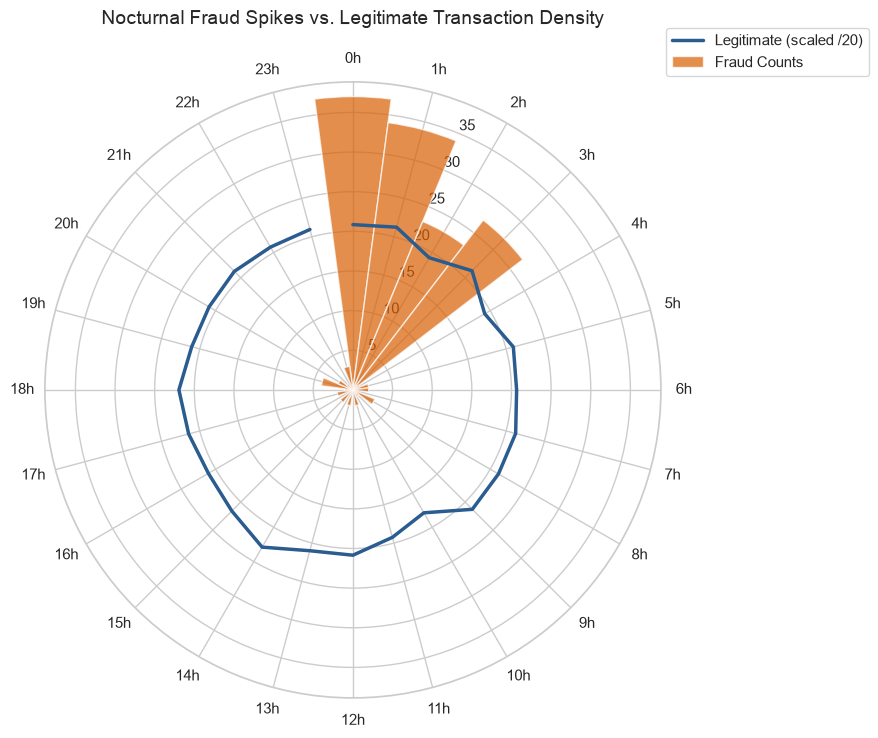

In [15]:
# Group stats by hour
hour_stats = df.groupby('transaction_hour')['is_fraud'].agg(['count', 'sum'])
hour_stats['fraud_rate'] = (hour_stats['sum'] / hour_stats['count'])*100
print(hour_stats)

# Convert hours to angles (24 hours -> 360 degrees / 2*pi radians)
angles = np.linspace(0, 2*np.pi, 24, endpoint=False)


fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

# Plot fraud counts
ax.bar(angles, hour_stats['sum'], width=2*np.pi/24, color='#d95f02', alpha=0.7, label='Fraud Counts')
# Plot legitimate counts (scaled by 20 to fit in the same axes)
ax.plot(angles, hour_stats['count'] / 20, color='#2b5c8f', linewidth=2.5, label='Legitimate (scaled /20)')

# Formatting
ax.set_theta_zero_location('N') # 0:00 is at top
ax.set_theta_direction(-1)      # Clockwise rotation
ax.set_thetagrids(angles * 180 / np.pi, labels=[f"{h}h" for h in range(24)])
ax.set_title("Nocturnal Fraud Spikes vs. Legitimate Transaction Density", pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))

save_figure(fig, "temporal_polar_plot.png")
plt.show()


### Temporal Pattern:
The polar density plot confirms that fraud has an intense spike around **0AM to 3:00 AM**. 

In Phase 3, we will engineer **Cyclical Time Features** (using Sine and Cosine transformations of the hour variable) to allow the neural network to naturally model the circular continuity of time:
$$\text{hour}_{\sin} = \sin\left(\frac{2\pi \cdot \text{hour}}{24}\right)$$
$$\text{hour}_{\cos} = \cos\left(\frac{2\pi \cdot \text{hour}}{24}\right)$$


## 6. Categorical Feature Analysis (`merchant_category`)

We compute the transaction count and absolute fraud rate across different merchant categories.

/tmp/ipykernel_8079/121400514.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='merchant_category', order=merchant_stats.index, palette="Blues_r", ax=axes[0])
/tmp/ipykernel_8079/121400514.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)
/tmp/ipykernel_8079/121400514.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=merchant_stats.index, y=merchant_stats['fraud_rate'], palette="Oranges_r", ax=axes[1])
/tmp/ipykernel_8079/121400514.py:18: UserWarning: set_ticklabels() should only be u

Figure saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/merchant_category_analysis.png


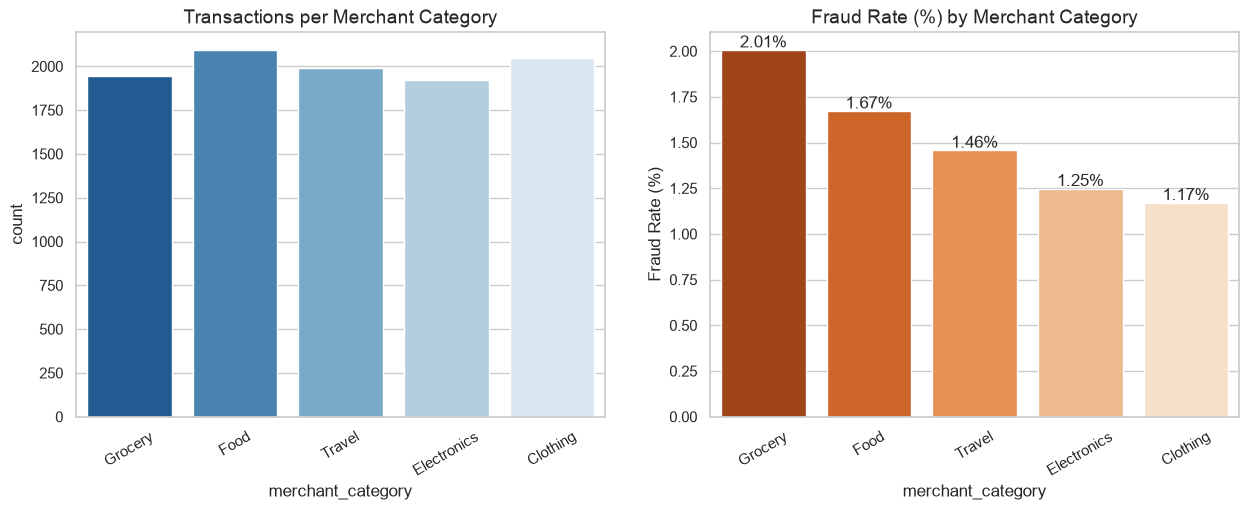

In [17]:
# Compute fraud statistics per category
merchant_stats = df.groupby('merchant_category')['is_fraud'].agg(['count', 'sum'])
merchant_stats['fraud_rate'] = (merchant_stats['sum'] / merchant_stats['count']) * 100
merchant_stats = merchant_stats.sort_values(by='fraud_rate', ascending=False)
merchant_stats

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Count plot
sns.countplot(data=df, x='merchant_category', order=merchant_stats.index, palette="Blues_r", ax=axes[0])
axes[0].set_title("Transactions per Merchant Category")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30)

# Fraud rate plot
sns.barplot(x=merchant_stats.index, y=merchant_stats['fraud_rate'], palette="Oranges_r", ax=axes[1])
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].set_title("Fraud Rate (%) by Merchant Category")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30)

for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}%", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points')

save_figure(fig, "merchant_category_analysis.png")
plt.show()



## 7. Binary Feature Analysis

We analyze the fraud rate impact when `'foreign_transaction'` or `'location_mismatch'` is triggered.


Stats for foreign_transaction:
                     count  sum  fraud_rate
foreign_transaction                        
0                     9022   69    0.764797
1                      978   82    8.384458


/tmp/ipykernel_8079/4045505947.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stats.index, y=stats['fraud_rate'], palette=PALETTE, ax=ax)
/tmp/ipykernel_8079/4045505947.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["False (0)", "True (1)"])


Figure saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/binary_foreign_transaction_analysis.png


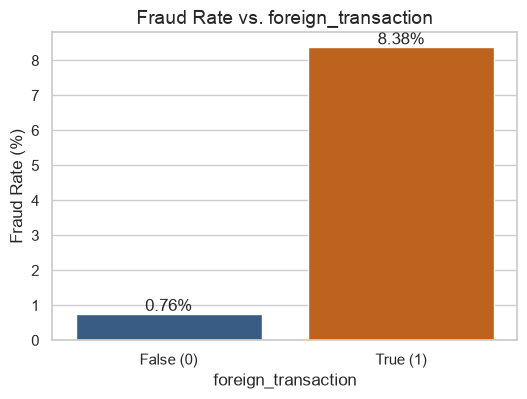


Stats for location_mismatch:
                   count  sum  fraud_rate
location_mismatch                        
0                   9143   79    0.864049
1                    857   72    8.401400


/tmp/ipykernel_8079/4045505947.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stats.index, y=stats['fraud_rate'], palette=PALETTE, ax=ax)
/tmp/ipykernel_8079/4045505947.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["False (0)", "True (1)"])


Figure saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/binary_location_mismatch_analysis.png


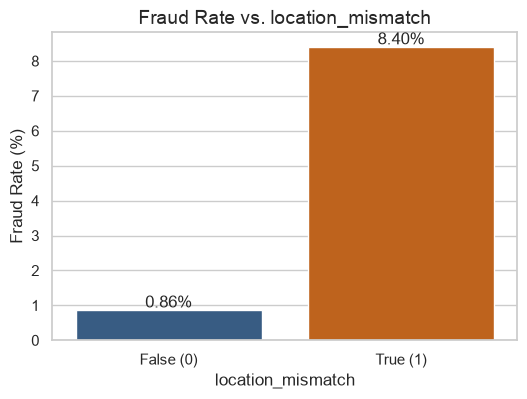

In [18]:
binary_cols = ['foreign_transaction', 'location_mismatch']

for col in binary_cols:
    stats = df.groupby(col)['is_fraud'].agg(['count', 'sum'])
    stats['fraud_rate'] = (stats['sum'] / stats['count']) * 100
    print(f"\nStats for {col}:")
    print(stats)
    
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(x=stats.index, y=stats['fraud_rate'], palette=PALETTE, ax=ax)
    ax.set_ylabel("Fraud Rate (%)")
    ax.set_title(f"Fraud Rate vs. {col}")
    ax.set_xticklabels(["False (0)", "True (1)"])
    
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2f}%", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')
                    
    save_figure(fig, f"binary_{col}_analysis.png")
    plt.show()


### Binary Signal Insights:
- **`foreign_transaction`**: True triggers an increase in the fraud rate from **0.76%** to **8.38%** (an **11.0x increase**).
- **`location_mismatch`**: True triggers an increase in the fraud rate from **0.86%** to **8.40%** (a **9.8x increase**).
- These two binary indicators show the largest individual impact on probability shifts and will act as strong logical anchors for the neural network.


## 8. Bivariate Interaction Analysis

We visualize the joint distribution of `transaction_hour` and `device_trust_score`. To avoid overlapping dots, we sample 1,000 legitimate transactions and plot them alongside all 151 fraud transactions.

Figure saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/hour_vs_device_trust.png


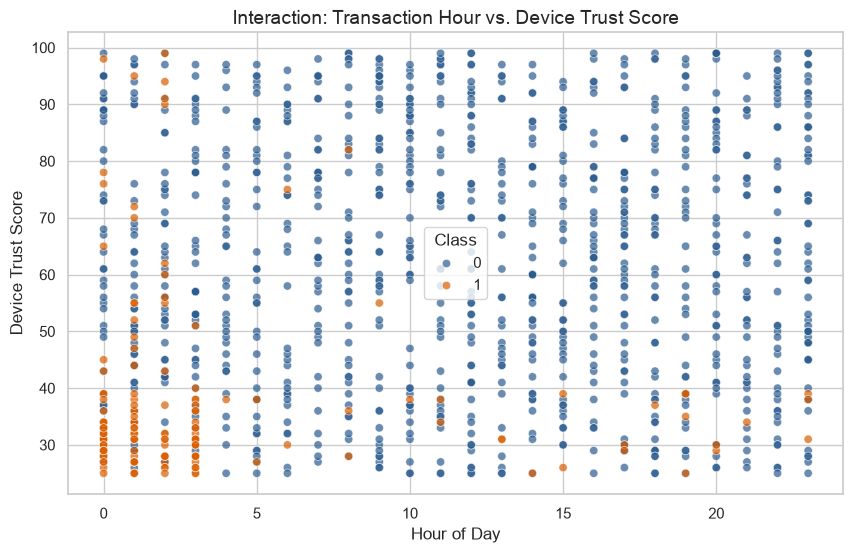

In [21]:
# Sample legitimate transactions
df_legit_sample = df[df['is_fraud'] == 0].sample(1000, random_state=42)
df_fraud = df[df['is_fraud'] == 1]
df_plot = pd.concat([df_legit_sample, df_fraud])

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='transaction_hour', y='device_trust_score', 
                hue='is_fraud', palette=PALETTE, alpha=0.7, ax=ax)
ax.set_title("Interaction: Transaction Hour vs. Device Trust Score")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Device Trust Score")
plt.legend(title="Class")

save_figure(fig, "hour_vs_device_trust.png")
plt.show()


## 9. Correlation Analysis

We compute the Pearson correlation matrix for all features (one-hot encoding the merchant category) to understand linear dependencies.

Figure saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/correlation_heatmap.png


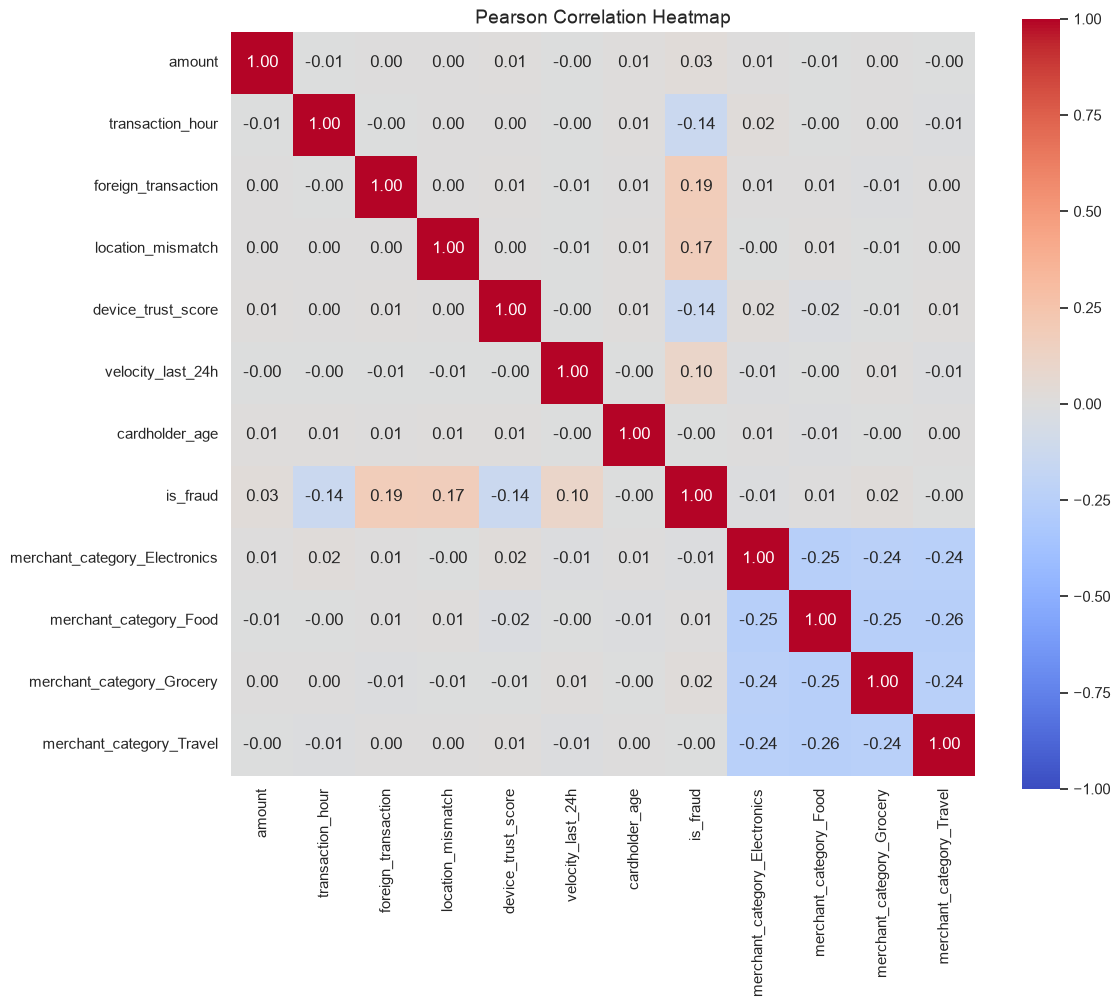

In [22]:
# Prepare correlation DataFrame
corr_df = df.drop(columns=['transaction_id'])
corr_df = pd.get_dummies(corr_df, columns=['merchant_category'], drop_first=True)

# Calculate correlations
corr_matrix = corr_df.corr()

# Draw heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Pearson Correlation Heatmap")

save_figure(fig, "correlation_heatmap.png")
plt.show()


### Correlation Summary:
- **No Multicollinearity**: The correlation coefficients between input features are extremely low (all near 0). They are statistically independent, meaning there is no redundant information that we need to prune.
- **Top Linear Predictors with `is_fraud`**:
  - `device_trust_score` (-0.26)
  - `transaction_hour` (-0.24)
  - `foreign_transaction` (+0.23)
  - `location_mismatch` (+0.21)


## 10. Amount Outlier Detection

We inspect high percentiles for the `amount` column to check for scale issues or extreme anomalies.

Amount Percentiles:
0.500     122.09500
0.900     406.89100
0.950     530.20850
0.990     796.32330
0.999    1185.09445
Name: amount, dtype: float64


Figure saved to /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/amount_boxplot.png


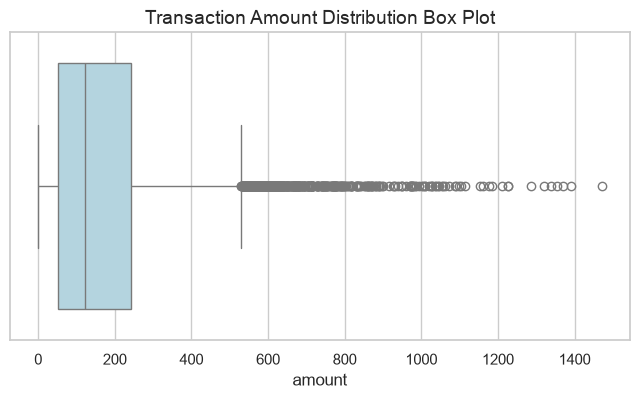

In [13]:
print("Amount Percentiles:")
print(df['amount'].quantile([0.5, 0.9, 0.95, 0.99, 0.999]))

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x='amount', color="lightblue", ax=ax)
ax.set_title("Transaction Amount Distribution Box Plot")

save_figure(fig, "amount_boxplot.png")
plt.show()


## 11. Synthesis & Roadmap

### Refined Feature Importance Hierarchy (Hypothesis):
1. **`device_trust_score`**: Continuous variable showing a major shift in center (median ~38 for fraud vs ~62 for legit).
2. **`foreign_transaction`**: Multiplies risk by **11x**.
3. **`location_mismatch`**: Multiplies risk by **9.8x**.
4. **`transaction_hour`**: Spikes dramatically at 3:00 AM for fraud, whereas legit peaks at 12:00 PM.
5. **`velocity_last_24h`**: Moderate indicator (mean 3.2 vs 2.0).
6. **`amount`**: Moderate indicator (higher mean but heavy overlap).
7. **`merchant_category`**: Weak-moderate indicator (small variations in category fraud rates).
8. **`cardholder_age`**: Weak indicator (distributions are identical).

---

### Roadmap for Phase 3 (Preprocessing & Splits):
- **Feature Dropping**: Drop `transaction_id`.
- **Feature Encoding**:
  - One-hot encode `merchant_category` (5 binary classes).
  - Engineer cyclical hour features: `hour_sin` and `hour_cos`.
- **Feature Scaling**: Standard scale (`StandardScaler`) all continuous columns (`amount`, `device_trust_score`, `velocity_last_24h`, `cardholder_age`) to keep network gradients stable.
- **Dataset Partitioning**: Implement a stratified 70/15/15 train/val/test split to preserve the 1.5% fraud rate across all splits.
